# Guide Capture Comparison

Compare guide capture efficiency across datasets:
- Cells per guide distributions
- Guides per cell distributions  
- Guide UMI distributions

**Input:** `latest_qc_paths.tsv` and `latest_mudata_paths.tsv`  
**Output:** Guide capture comparison plots

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
# Project root
PROJECT_ROOT = Path("/cellar/users/aklie/data/datasets/tf_perturb_seq")

# Add config to path for color loader
sys.path.append(str(PROJECT_ROOT / "config"))
from loader import load_colors

dataset_colors = load_colors("technology-benchmark_WTC11_TF-Perturb-seq", "dataset_colors")
dataset_order = load_colors("technology-benchmark_WTC11_TF-Perturb-seq", "dataset_order")

In [3]:
# Paths
RUN_LABEL = "sceptre_v11"  # Change to "cleanser_unified" etc. to switch runs
BASE_DIR = PROJECT_ROOT / "datasets" / "technology-benchmark_WTC11_TF-Perturb-seq"
QC_PATHS_FILE = BASE_DIR / "manifests" / f"{RUN_LABEL}_qc_paths.tsv"
OUTPUT_DIR = BASE_DIR / "results" / "cross_tech_comparison" / RUN_LABEL
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Reading paths from: {QC_PATHS_FILE}")
print(f"Output directory: {OUTPUT_DIR}")

Reading paths from: /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/manifests/sceptre_v11_qc_paths.tsv
Output directory: /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/results/cross_tech_comparison/sceptre_v11


In [4]:
# Load the paths manifest
paths_df = pd.read_csv(QC_PATHS_FILE, sep="\t")
paths_df

,dataset,qc_dir,gene_metrics,guide_metrics,intended_target_results,intended_target_metrics,trans_results,trans_metrics
0,Hon_WTC11-benchmark_TF-Perturb-seq,/cellar/users/aklie/data/datasets/tf_perturb_s...,gene/gene_metrics.tsv,guide/guide_metrics.tsv,intended_target/intended_target_results.tsv,intended_target/intended_target_metrics.tsv,trans/trans_results.tsv,trans/trans_metrics.tsv
1,Huangfu_WTC11-benchmark_TF-Perturb-seq,/cellar/users/aklie/data/datasets/tf_perturb_s...,gene/gene_metrics.tsv,guide/guide_metrics.tsv,intended_target/intended_target_results.tsv,intended_target/intended_target_metrics.tsv,trans/trans_results.tsv,trans/trans_metrics.tsv
2,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3,/cellar/users/aklie/data/datasets/tf_perturb_s...,gene/gene_metrics.tsv,guide/guide_metrics.tsv,intended_target/intended_target_results.tsv,intended_target/intended_target_metrics.tsv,trans/trans_results.tsv,trans/trans_metrics.tsv
3,Engreitz_WTC11-benchmark_TF-Perturb-seq,/cellar/users/aklie/data/datasets/tf_perturb_s...,gene/gene_metrics.tsv,guide/guide_metrics.tsv,intended_target/intended_target_results.tsv,intended_target/intended_target_metrics.tsv,trans/trans_results.tsv,trans/trans_metrics.tsv


## Guide Metrics Overview

In [5]:
# Load and combine guide metrics
guide_metrics_list = []
for _, row in paths_df.iterrows():
    guide_path = Path(row['qc_dir']) / row['guide_metrics']
    if guide_path.exists():
        df = pd.read_csv(guide_path, sep="\t")
        df['dataset'] = row['dataset']
        guide_metrics_list.append(df)
    else:
        print(f"Warning: {guide_path} not found")

guide_metrics_df = pd.concat(guide_metrics_list, ignore_index=True)
guide_metrics_df.head()

,batch,n_cells,guide_umi_median,guide_umi_mean,guide_umi_std,guide_umi_min,guide_umi_max,guide_umi_q25,guide_umi_q75,guides_per_cell_mean,...,n_cells_with_guide,n_cells_exactly_1_guide,frac_cells_with_guide,n_guides_total,cells_per_guide_median,cells_per_guide_mean,cells_per_guide_std,cells_per_guide_min,cells_per_guide_max,dataset
0,all,57775,799.0,1001.025720,871.062384,1.0,8285.0,308.0,1423.0,1.887148,...,56338,27412,0.975128,416.0,214.5,262.091346,271.302572,1.0,2049.0,Hon_WTC11-benchmark_TF-Perturb-seq
1,IGVFDS6244NAXC,24991,800.0,995.742107,880.186586,1.0,8285.0,272.0,1431.0,1.638790,...,23818,12714,0.953063,NaN,NaN,NaN,NaN,NaN,NaN,Hon_WTC11-benchmark_TF-Perturb-seq
2,IGVFDS8721BKRO,7255,516.0,776.835975,784.736293,1.0,7033.0,182.0,1132.0,2.617229,...,7135,3071,0.983460,NaN,NaN,NaN,NaN,NaN,NaN,Hon_WTC11-benchmark_TF-Perturb-seq
3,IGVFDS9613DDRB,25529,869.0,1069.909711,874.487143,6.0,7780.0,399.0,1489.0,1.922794,...,25385,11627,0.994359,NaN,NaN,NaN,NaN,NaN,NaN,Hon_WTC11-benchmark_TF-Perturb-seq
4,all,141251,99.0,215.444875,271.601295,1.0,4558.0,33.0,308.0,1.145698,...,107604,72094,0.761793,416.0,336.5,389.016827,434.979321,6.0,3826.0,Huangfu_WTC11-benchmark_TF-Perturb-seq


In [6]:
# Filter to 'all' batch (aggregate metrics)
guide_all = guide_metrics_df[guide_metrics_df['batch'] == 'all'].copy()
guide_all['dataset'] = pd.Categorical(guide_all['dataset'], categories=dataset_order, ordered=True)
guide_all = guide_all.sort_values('dataset')
guide_all

,batch,n_cells,guide_umi_median,guide_umi_mean,guide_umi_std,guide_umi_min,guide_umi_max,guide_umi_q25,guide_umi_q75,guides_per_cell_mean,...,n_cells_with_guide,n_cells_exactly_1_guide,frac_cells_with_guide,n_guides_total,cells_per_guide_median,cells_per_guide_mean,cells_per_guide_std,cells_per_guide_min,cells_per_guide_max,dataset
0,all,57775,799.0,1001.025720,871.062384,1.0,8285.0,308.0,1423.0,1.887148,...,56338,27412,0.975128,416.0,214.5,262.091346,271.302572,1.0,2049.0,Hon_WTC11-benchmark_TF-Perturb-seq
4,all,141251,99.0,215.444875,271.601295,1.0,4558.0,33.0,308.0,1.145698,...,107604,72094,0.761793,416.0,336.5,389.016827,434.979321,6.0,3826.0,Huangfu_WTC11-benchmark_TF-Perturb-seq
9,all,50993,430.0,943.872433,1244.500342,1.0,17324.0,52.0,1418.0,1.618850,...,46897,23840,0.919675,416.0,150.0,198.437500,239.281748,2.0,1926.0,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3
13,all,434062,4.0,16.386813,39.851022,1.0,1020.0,2.0,8.0,0.309124,...,101507,75702,0.233854,416.0,294.0,322.545673,334.392955,1.0,3246.0,Engreitz_WTC11-benchmark_TF-Perturb-seq


## Cells per Guide Comparison

In [7]:
# Cells per guide summary stats
cpg_cols = ['cells_per_guide_median', 'cells_per_guide_mean', 'cells_per_guide_std', 
            'cells_per_guide_min', 'cells_per_guide_max']
cpg_summary = guide_all[['dataset'] + cpg_cols].copy()
cpg_summary

,dataset,cells_per_guide_median,cells_per_guide_mean,cells_per_guide_std,cells_per_guide_min,cells_per_guide_max
0,Hon_WTC11-benchmark_TF-Perturb-seq,214.5,262.091346,271.302572,1.0,2049.0
4,Huangfu_WTC11-benchmark_TF-Perturb-seq,336.5,389.016827,434.979321,6.0,3826.0
9,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3,150.0,198.437500,239.281748,2.0,1926.0
13,Engreitz_WTC11-benchmark_TF-Perturb-seq,294.0,322.545673,334.392955,1.0,3246.0


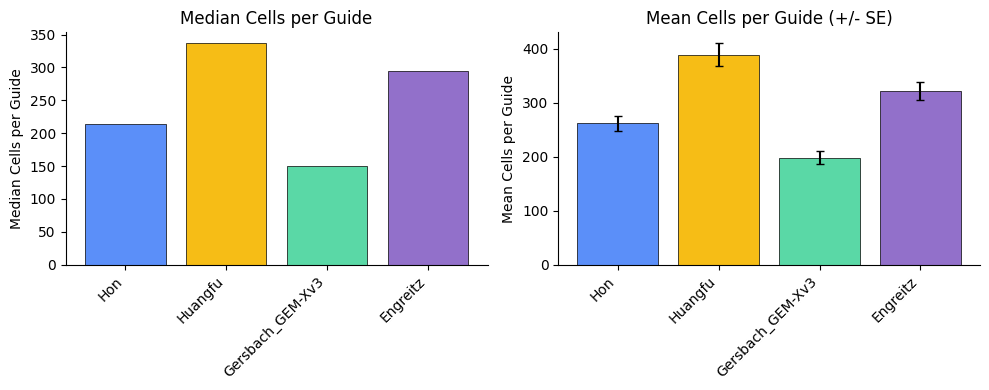

In [8]:
# Barplot of median cells per guide
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Median
ax = axes[0]
colors = [dataset_colors.get(ds, 'gray') for ds in guide_all['dataset']]
ax.bar(range(len(guide_all)), guide_all['cells_per_guide_median'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(guide_all)))
ax.set_xticklabels([ds.replace('_WTC11-benchmark_TF-Perturb-seq', '') for ds in guide_all['dataset']], 
                   rotation=45, ha='right')
ax.set_ylabel('Median Cells per Guide')
ax.set_title('Median Cells per Guide')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mean with std error bars
ax = axes[1]
ax.bar(range(len(guide_all)), guide_all['cells_per_guide_mean'], 
       yerr=guide_all['cells_per_guide_std'] / np.sqrt(guide_all['n_guides_total']),
       color=colors, edgecolor='black', linewidth=0.5, capsize=3)
ax.set_xticks(range(len(guide_all)))
ax.set_xticklabels([ds.replace('_WTC11-benchmark_TF-Perturb-seq', '') for ds in guide_all['dataset']], 
                   rotation=45, ha='right')
ax.set_ylabel('Mean Cells per Guide')
ax.set_title('Mean Cells per Guide (+/- SE)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cells_per_guide_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Guides per Cell Comparison

In [9]:
# Guides per cell summary stats
gpc_cols = ['guides_per_cell_median', 'guides_per_cell_mean', 'guides_per_cell_std',
            'guides_per_cell_min', 'guides_per_cell_max']
gpc_summary = guide_all[['dataset'] + gpc_cols].copy()
gpc_summary

,dataset,guides_per_cell_median,guides_per_cell_mean,guides_per_cell_std,guides_per_cell_min,guides_per_cell_max
0,Hon_WTC11-benchmark_TF-Perturb-seq,2.0,1.887148,1.490071,0,39
4,Huangfu_WTC11-benchmark_TF-Perturb-seq,1.0,1.145698,1.084107,0,26
9,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3,1.0,1.618850,1.053499,0,11
13,Engreitz_WTC11-benchmark_TF-Perturb-seq,0.0,0.309124,0.635092,0,8


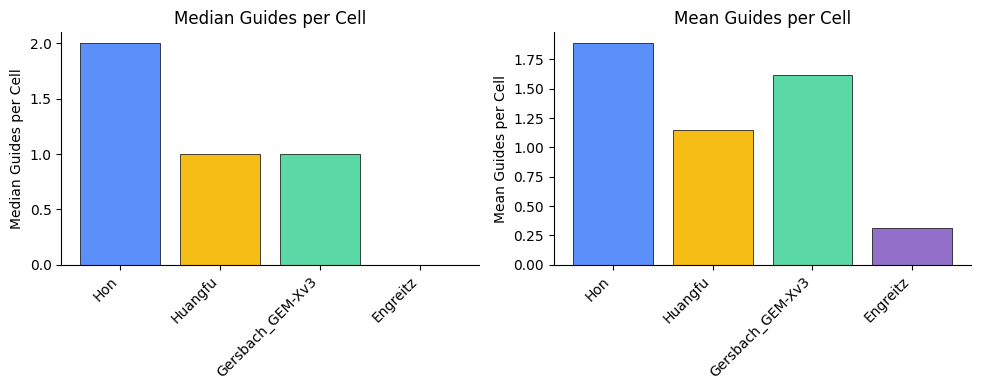

In [10]:
# Barplot of guides per cell
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Median
ax = axes[0]
colors = [dataset_colors.get(ds, 'gray') for ds in guide_all['dataset']]
ax.bar(range(len(guide_all)), guide_all['guides_per_cell_median'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(guide_all)))
ax.set_xticklabels([ds.replace('_WTC11-benchmark_TF-Perturb-seq', '') for ds in guide_all['dataset']], 
                   rotation=45, ha='right')
ax.set_ylabel('Median Guides per Cell')
ax.set_title('Median Guides per Cell')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mean
ax = axes[1]
ax.bar(range(len(guide_all)), guide_all['guides_per_cell_mean'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(guide_all)))
ax.set_xticklabels([ds.replace('_WTC11-benchmark_TF-Perturb-seq', '') for ds in guide_all['dataset']], 
                   rotation=45, ha='right')
ax.set_ylabel('Mean Guides per Cell')
ax.set_title('Mean Guides per Cell')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "guides_per_cell_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Guide UMI Comparison

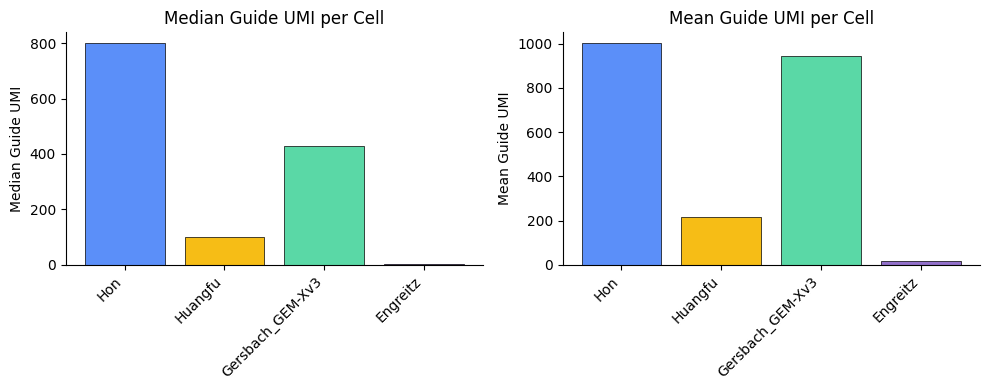

In [11]:
# Barplot of guide UMI stats
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Median
ax = axes[0]
colors = [dataset_colors.get(ds, 'gray') for ds in guide_all['dataset']]
ax.bar(range(len(guide_all)), guide_all['guide_umi_median'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(guide_all)))
ax.set_xticklabels([ds.replace('_WTC11-benchmark_TF-Perturb-seq', '') for ds in guide_all['dataset']], 
                   rotation=45, ha='right')
ax.set_ylabel('Median Guide UMI')
ax.set_title('Median Guide UMI per Cell')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mean
ax = axes[1]
ax.bar(range(len(guide_all)), guide_all['guide_umi_mean'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(guide_all)))
ax.set_xticklabels([ds.replace('_WTC11-benchmark_TF-Perturb-seq', '') for ds in guide_all['dataset']], 
                   rotation=45, ha='right')
ax.set_ylabel('Mean Guide UMI')
ax.set_title('Mean Guide UMI per Cell')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "guide_umi_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Guide Assignment Rates

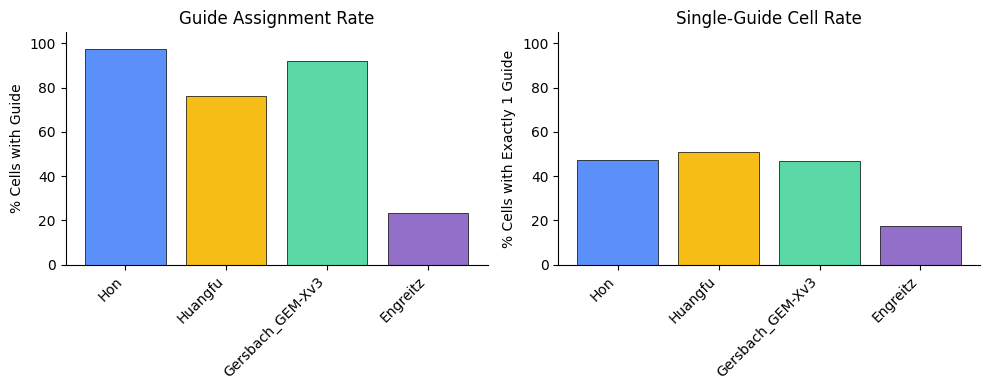

In [12]:
# Barplot of assignment rates
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Fraction of cells with guide
ax = axes[0]
colors = [dataset_colors.get(ds, 'gray') for ds in guide_all['dataset']]
ax.bar(range(len(guide_all)), guide_all['frac_cells_with_guide'] * 100, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(guide_all)))
ax.set_xticklabels([ds.replace('_WTC11-benchmark_TF-Perturb-seq', '') for ds in guide_all['dataset']], 
                   rotation=45, ha='right')
ax.set_ylabel('% Cells with Guide')
ax.set_title('Guide Assignment Rate')
ax.set_ylim(0, 105)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Cells with exactly 1 guide
ax = axes[1]
frac_single = guide_all['n_cells_exactly_1_guide'] / guide_all['n_cells'] * 100
ax.bar(range(len(guide_all)), frac_single, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(guide_all)))
ax.set_xticklabels([ds.replace('_WTC11-benchmark_TF-Perturb-seq', '') for ds in guide_all['dataset']], 
                   rotation=45, ha='right')
ax.set_ylabel('% Cells with Exactly 1 Guide')
ax.set_title('Single-Guide Cell Rate')
ax.set_ylim(0, 105)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "guide_assignment_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Summary Table

In [13]:
# Create summary table
summary_cols = [
    'dataset', 'n_cells', 'n_guides_total',
    'cells_per_guide_median', 'cells_per_guide_mean',
    'guides_per_cell_median', 'guides_per_cell_mean',
    'guide_umi_median', 'guide_umi_mean',
    'frac_cells_with_guide', 'n_cells_exactly_1_guide'
]
summary = guide_all[summary_cols].copy()
summary['pct_single_guide'] = summary['n_cells_exactly_1_guide'] / summary['n_cells'] * 100
summary

,dataset,n_cells,n_guides_total,cells_per_guide_median,cells_per_guide_mean,guides_per_cell_median,guides_per_cell_mean,guide_umi_median,guide_umi_mean,frac_cells_with_guide,n_cells_exactly_1_guide,pct_single_guide
0,Hon_WTC11-benchmark_TF-Perturb-seq,57775,416.0,214.5,262.091346,2.0,1.887148,799.0,1001.025720,0.975128,27412,47.446127
4,Huangfu_WTC11-benchmark_TF-Perturb-seq,141251,416.0,336.5,389.016827,1.0,1.145698,99.0,215.444875,0.761793,72094,51.039639
9,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3,50993,416.0,150.0,198.437500,1.0,1.618850,430.0,943.872433,0.919675,23840,46.751515
13,Engreitz_WTC11-benchmark_TF-Perturb-seq,434062,416.0,294.0,322.545673,0.0,0.309124,4.0,16.386813,0.233854,75702,17.440366


In [14]:
# Save summary
summary.to_csv(OUTPUT_DIR / "guide_capture_summary.tsv", sep="\t", index=False)
print(f"Saved to {OUTPUT_DIR / 'guide_capture_summary.tsv'}")

Saved to /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/results/cross_tech_comparison/sceptre_v11/guide_capture_summary.tsv


# DONE!

---